In [226]:
import numpy as np
import matplotlib.pyplot as plt
import pyabf
import os

In [ ]:
def analyze_rmp(abf_file, time_window=None):
    """
    Analyzes the resting membrane potential (RMP) from a current clamp ABF file
    and plots voltage, current, and RMP trends across sweeps.

    Parameters:
        abf_file (str): Path to the ABF file.
        time_window (list, optional): Time window [start, end] in milliseconds for RMP calculation.
                                      If None, the user is prompted to enter a time window.

    Returns:
        float: The average resting membrane potential across all sweeps.
    """

    # Load the ABF file
    abf = pyabf.ABF(abf_file)

    # Check if this is a current clamp recording
    if "mV" not in abf.sweepLabelY:
        print(f"Skipping {abf_file}: Not a current clamp recording.")
        return None  # Return None if not a valid file

    print(f"Processing {abf_file} as a current clamp recording...")

    # Prompt user for time window if not provided
    if time_window is None:
        start_time = float(input("Enter start of time window (ms): "))
        end_time = float(input("Enter end of time window (ms): "))
        time_window = [start_time, end_time]

    print(f"Using time window: {time_window[0]} ms to {time_window[1]} ms")

    # Initialize lists to store data
    resting_membrane_potentials = []  # Store RMP for each sweep
    sweep_duration = abf.sweepX[-1] * 1000  # Convert last time point to ms

    # Loop through all sweeps
    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep)

        # Calculate RMP within the time window
        time_idx = (abf.sweepX * 1000 >= time_window[0]) & (abf.sweepX * 1000 <= time_window[1])
        rmp = np.mean(abf.sweepY[time_idx])  # Mean voltage in time window
        resting_membrane_potentials.append(rmp)

    # Validate that the number of sweeps matches the RMP array length
    assert len(resting_membrane_potentials) == abf.sweepCount, "Mismatch between sweep count and RMP entries!"

    # Calculate the average RMP across all sweeps
    avg_rmp = np.mean(resting_membrane_potentials)

    # Print results for verification
    print(f"Resting Membrane Potentials: {resting_membrane_potentials}")
    print(f"Average RMP: {avg_rmp:.2f} mV")

    # Plot Resting Membrane Potential vs. Sweep Number
    plt.figure(figsize=(6, 4))
    sweep_numbers = np.arange(1, abf.sweepCount + 1)
    plt.plot(sweep_numbers, resting_membrane_potentials, marker="o", linestyle="-", color="g", label="RMP per Sweep")

    # Add a horizontal line for the average RMP
    plt.axhline(avg_rmp, color="black", linestyle="--", linewidth=2, label=f"Avg RMP: {avg_rmp:.2f} mV")

    # Add text annotation for average RMP
    plt.text(sweep_numbers[-1], avg_rmp + 1, f"Avg RMP: {avg_rmp:.2f} mV",
             verticalalignment="bottom", horizontalalignment="right", fontsize=10, color="black")

    plt.title("Resting Membrane Potential Over Sweeps")
    plt.ylabel("RMP (mV)")
    plt.xlabel("Sweep Number")
    plt.legend()
    plt.grid()
    plt.show()

    return avg_rmp  # Return the average RMP

Processing /Users/jayashri/Desktop/02282025/25228002.abf as a current clamp recording...


Enter start of time window (ms):  200
Enter end of time window (ms):  220


Using time window: 200.0 ms to 220.0 ms
Resting Membrane Potentials: [-53.48941, -53.660095, -53.461914, -52.233944, -51.51974, -53.956482, -54.845825, -54.456726, -56.0191, -57.029358, -55.21057, -57.86801, -58.36645, -57.465454, -58.616394, -59.007324, -59.06293, -60.043243, -60.307186]
Average RMP: -56.14 mV


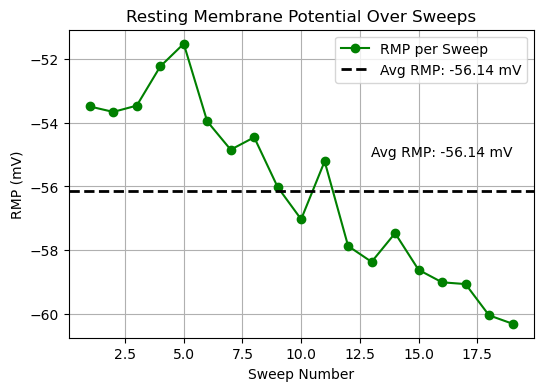

-56.1379

In [242]:
#Example Uses

analyze_rmp('/Users/jayashri/Desktop/02282025/25228002.abf')
#analyze_rmp('/Users/jayashri/Desktop/02282025/25228002.abf', time_window=[200, 220])

#avg_rmp = analyze_rmp('/Users/jayashri/Desktop/02282025/25228002.abf', time_window=[200, 220])
#print(avg_rmp)

Text(0.5, 0.01, 'Time (ms)')

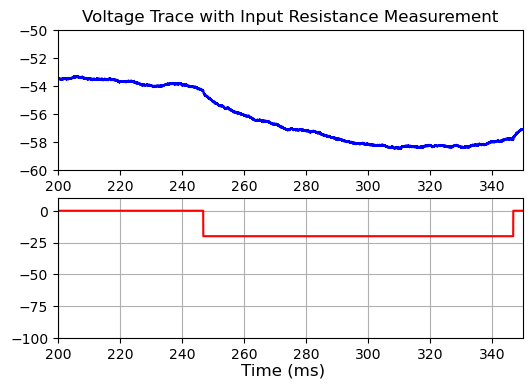

In [224]:
abf = pyabf.ABF('/Users/jayashri/Desktop/02282025/25228002.abf')

fig, axes = plt.subplots(2, 1, figsize=(6, 4))


#Voltage Trace
axes[0].plot(abf.sweepX * 1000, abf.sweepY, color="b")
axes[0].set_title("Voltage Trace with Input Resistance Measurement")
plt.grid()


#Current Command 
axes[1].plot(abf.sweepX * 1000, abf.sweepC, color="r")

axes[0].set_xlim(200, 350)
axes[0].set_ylim(-60, -50)
axes[1].set_xlim(200, 350)
axes[1].set_ylim(-100, 10)


fig.supxlabel("Time (ms)")

In [238]:
#Given a directory, get all the current clamp files and their respective protocols. 

def get_current_clamp_files(directory):
    """
    Identify all current clamp ABF files in a directory and extract their protocols.

    Parameters:
        directory (str): The path to the folder containing ABF files.

    Returns:
        dict: {filename: protocol_name} for all current clamp files.
    """
    current_clamp_files = {}

    for file in os.listdir(directory):
        if file.endswith(".abf"):
            file_path = os.path.join(directory, file)
            abf = pyabf.ABF(file_path)

            # Check if the recording is a Current Clamp
            if "mV" in abf.sweepLabelY:
                protocol_name = abf.protocol if abf.protocol else "Unknown"
                current_clamp_files[file] = protocol_name

    return current_clamp_files

In [240]:
# Example usage:
directory = "/Users/jayashri/Desktop/03232025"
cc_files = get_current_clamp_files(directory)

# Print results
for filename, protocol in cc_files.items():
    print(f"{filename}: {protocol}")

25323014.abf: 3_CC_spont
25323001.abf: 2_CC_steps
25323003.abf: 2_CC_steps
25323007.abf: 2_CC_steps
25323013.abf: 2_CC_steps
25323011.abf: 2_CC_steps
25323010.abf: 2_CC_steps
25323004.abf: 3_CC_spont
25323009.abf: 2_CC_steps


In [236]:
pyabf.help()
